# Économétrie — Analyse des données d'assistance automobile

**Objectif** : Appliquer des modèles économétriques pour expliquer et quantifier les relations
entre les variables du jeu de données d'assistance automobile 2021-2022.

**Plan :**
1. Imports & chargement des données nettoyées
2. Statistiques descriptives et tests préliminaires
3. Modèle de régression linéaire (OLS)
4. Tests de validité du modèle
5. Modèles alternatifs (Logit/Probit si variable binaire)
6. Interprétation des résultats
7. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR    = Path().resolve().parent / 'data'
REPORTS_DIR = Path().resolve().parent / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('muted')

df = pd.read_csv(DATA_DIR / 'dossiers_enrichis.csv', encoding='utf-8-sig',
                 parse_dates=['date.ouverture'])
df['mois'] = df['date.ouverture'].dt.month
print(f'Données chargées : {len(df):,} lignes, {len(df.columns)} colonnes')
df.head()

Données chargées : 101,206 lignes, 24 colonnes


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,...,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties,flag_auto_creation,mois_ouverture,temps_total_sec,nb_intervenants,temps_total_min,Apprentissage_Test,mois
0,7494402,C5,F99,2021-02-11,10:38:00,326,Panne mécanique,2021-02-11,Diesel,MCS,...,0,0.0,0.0,0,2021-02,623.0,1.0,10.383333,Apprentissage,2.0
1,7569082,C4,F14,2022-07-12,18:40:00,1164,Panne mécanique,2022-07-12,Essence,MCS,...,0,0.0,0.0,0,2022-07,284.0,1.0,4.733333,Apprentissage,7.0
2,8111190,C0,F1,2021-01-08,12:32:00,1337,Panne mécanique,2021-01-08,Essence,MCS,...,0,0.0,0.0,0,2021-01,1849.0,7.0,30.816667,Apprentissage,1.0
3,5630809,C7,F72,2021-11-08,19:46:00,1322,Panne mécanique,2021-11-08,Essence,MCS,...,0,0.0,0.0,0,2021-11,988.0,1.0,16.466667,Apprentissage,11.0
4,8179409,C4,F4,2021-08-11,18:12:00,2306,Panne mécanique,2021-08-11,Essence,Higgins,...,0,0.0,0.0,0,2021-08,1133.0,2.0,18.883333,Apprentissage,8.0


## 1. Statistiques descriptives et tests préliminaires

Avant d'ajuster un modèle, on vérifie les distributions, les corrélations et les hypothèses de base.

=== Statistiques descriptives ===


,temps_total_min,nb_intervenants,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup
count,98948.00,98948.00,101206.00,101206.0,101206.00,101206.00,101178.00
mean,19.96,3.19,0.92,0.1,0.08,0.01,0.04
std,35.73,3.78,0.27,0.3,0.28,0.12,0.20
min,0.00,1.00,0.00,0.0,0.00,0.00,0.00
25%,4.48,1.00,1.00,0.0,0.00,0.00,0.00
50%,9.40,2.00,1.00,0.0,0.00,0.00,0.00
75%,21.25,4.00,1.00,0.0,0.00,0.00,0.00
max,4271.70,110.00,1.00,1.0,1.00,1.00,1.00



Shapiro-Wilk sur temps_total_min (n=5 000) : W=0.5391, p=2.12e-78
→ Distribution non normale (p < 0.05)


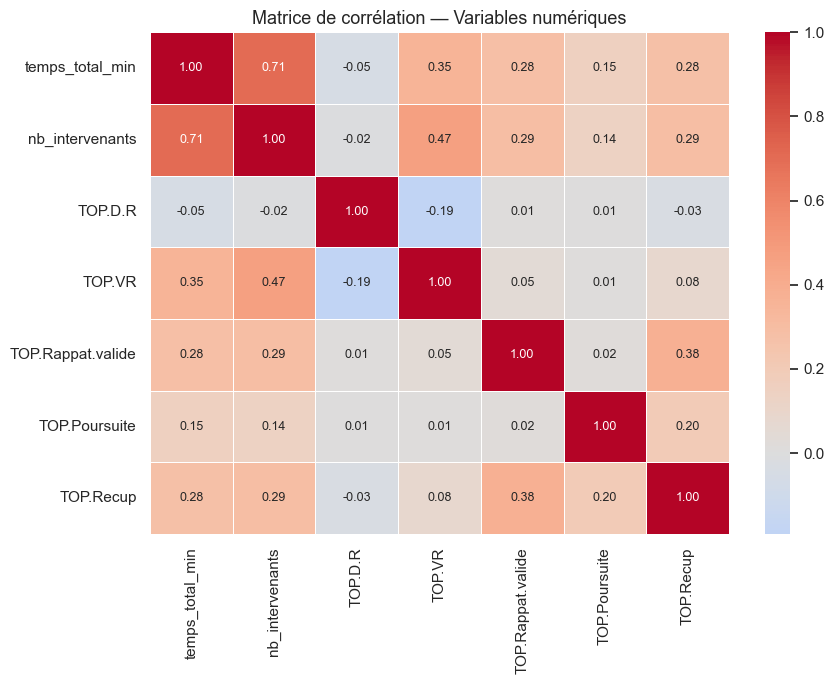

In [2]:
NUM_COLS = [c for c in ['temps_total_min', 'nb_intervenants', 'TOP.D.R', 'TOP.VR',
                        'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup'] if c in df.columns]

print('=== Statistiques descriptives ===')
display(df[NUM_COLS].describe().round(2))

stat, p = stats.shapiro(df['temps_total_min'].dropna().sample(5000, random_state=42))
print(f'\nShapiro-Wilk sur temps_total_min (n=5 000) : W={stat:.4f}, p={p:.2e}')
print('→ Distribution non normale (p < 0.05)' if p < 0.05 else '→ Distribution normale')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[NUM_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_econo_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Modèle de régression linéaire (OLS)

**Variable expliquée** : `temps_total_min` (durée de traitement du dossier)

**Variables explicatives** : à définir selon les résultats de l'exploration

In [3]:
base = df[df['Apprentissage_Test'] == 'Apprentissage'].copy() if 'Apprentissage_Test' in df.columns else df.copy()
base = base[['temps_total_min', 'nb_intervenants', 'TOP.D.R', 'TOP.VR',
             'TOP.Rappat.valide', 'Outil.d.assistance', 'mois']].dropna()
base.columns = base.columns.str.replace('.', '_', regex=False)

ols = smf.ols(
    'temps_total_min ~ nb_intervenants + TOP_D_R + TOP_VR + TOP_Rappat_valide + C(Outil_d_assistance) + C(mois)',
    data=base
).fit()
print(ols.summary())

pd.DataFrame({
    'coef'     : ols.params,
    'p_value'  : ols.pvalues,
    'conf_inf' : ols.conf_int()[0],
    'conf_sup' : ols.conf_int()[1],
}).round(4).to_csv(REPORTS_DIR / 'econo_ols_coefficients.csv', encoding='utf-8-sig')

                            OLS Regression Results                            
Dep. Variable:        temps_total_min   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     8296.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        11:11:15   Log-Likelihood:            -4.0232e+05
No. Observations:               87963   AIC:                         8.047e+05
Df Residuals:                   87946   BIC:                         8.048e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## 3. Tests de validité

Vérification des hypothèses du modèle : normalité des résidus, homoscédasticité, multicolinéarité.

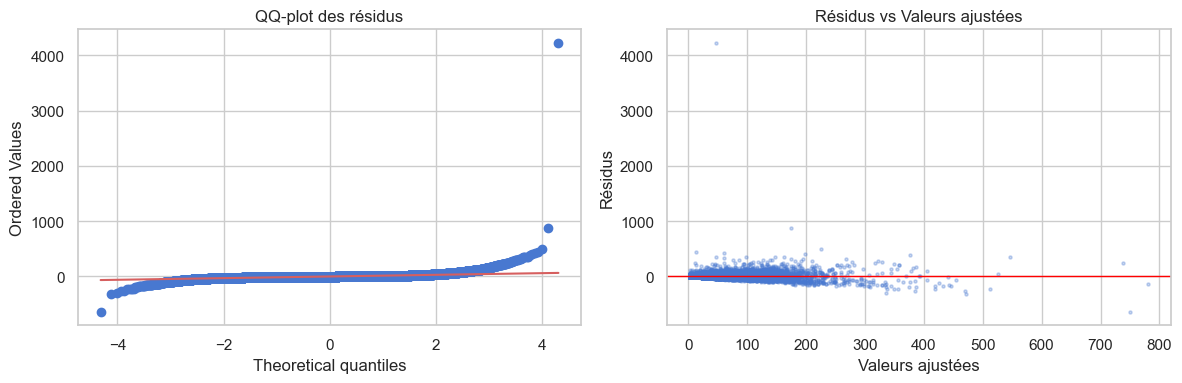

Breusch-Pagan : stat=71.5358, p=5.36e-09
→ Hétéroscédasticité détectée

=== VIF (multicolinéarité) ===


,Variable,VIF
0,nb_intervenants,2.38
1,TOP_D_R,1.63
2,TOP_VR,1.45
3,TOP_Rappat_valide,1.21


In [4]:
residus = ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residus, plot=axes[0])
axes[0].set_title('QQ-plot des résidus', fontsize=12)
axes[1].scatter(ols.fittedvalues, residus, alpha=0.3, s=5, color=COLORS[0])
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('Valeurs ajustées')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus vs Valeurs ajustées', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_econo_residus.png', dpi=150, bbox_inches='tight')
plt.show()

bp_stat, bp_p, _, _ = sms.het_breuschpagan(residus, ols.model.exog)
print(f'Breusch-Pagan : stat={bp_stat:.4f}, p={bp_p:.2e}')
print('→ Hétéroscédasticité détectée' if bp_p < 0.05 else '→ Homoscédasticité')

X_vif = base[['nb_intervenants', 'TOP_D_R', 'TOP_VR', 'TOP_Rappat_valide']]
vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).round(2)
print('\n=== VIF (multicolinéarité) ===')
vif.to_csv(REPORTS_DIR / 'econo_vif.csv', index=False, encoding='utf-8-sig')
vif

## 4. Modèle Logit — Variable binaire

**Variable expliquée** : `TOP.VR` (activation du véhicule de remplacement, 0/1)

Ce modèle identifie les facteurs qui augmentent la probabilité qu'un dossier déclenche un véhicule de remplacement.

In [5]:
data_logit = df[['TOP.VR', 'nb_intervenants', 'TOP.D.R', 'TOP.Rappat.valide',
                  'Outil.d.assistance', 'mois']].dropna().copy()
data_logit.columns = data_logit.columns.str.replace('.', '_', regex=False)
data_logit['TOP_VR'] = data_logit['TOP_VR'].astype(int)

logit = smf.logit(
    'TOP_VR ~ nb_intervenants + TOP_D_R + TOP_Rappat_valide + C(Outil_d_assistance) + C(mois)',
    data=data_logit
).fit(disp=0)
print(logit.summary())

odds = np.exp(logit.params).rename('Odds Ratio').round(3)
odds.to_csv(REPORTS_DIR / 'econo_logit_odds_ratios.csv', encoding='utf-8-sig')
print('\n=== Odds Ratios ===')
odds

                           Logit Regression Results                           
Dep. Variable:                 TOP_VR   No. Observations:                98938
Model:                          Logit   Df Residuals:                    98922
Method:                           MLE   Df Model:                           15
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.2957
Time:                        11:11:23   Log-Likelihood:                -23202.
converged:                       True   LL-Null:                       -32943.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -2.2058      0.058    -37.941      0.000      -2.320      -2.092
C(Outil_d_assistance)[T.MCS]     0.2434      0.033      7.427      0.000     

Intercept                       0.110
C(Outil_d_assistance)[T.MCS]    1.276
C(mois)[T.2.0]                  1.102
C(mois)[T.3.0]                  1.055
C(mois)[T.4.0]                  1.069
C(mois)[T.5.0]                  0.994
C(mois)[T.6.0]                  0.980
C(mois)[T.7.0]                  0.653
C(mois)[T.8.0]                  0.620
C(mois)[T.9.0]                  1.045
C(mois)[T.10.0]                 1.058
C(mois)[T.11.0]                 1.067
C(mois)[T.12.0]                 1.261
nb_intervenants                 1.453
TOP_D_R                         0.154
TOP_Rappat_valide               0.297
Name: Odds Ratio, dtype: float64

## 5. Interprétation et conclusion

In [6]:
print('=== Synthèse OLS ===')
print(f'R²        : {ols.rsquared:.3f}')
print(f'R² ajusté : {ols.rsquared_adj:.3f}')
print(f'F-stat    : {ols.fvalue:.2f}  (p={ols.f_pvalue:.2e})')
print(f'AIC       : {ols.aic:.1f}')
print()
print(f'Variables significatives (p < 0.05) : {ols.pvalues[ols.pvalues < 0.05].index.tolist()}')
print()
print('=== Synthèse Logit ===')
print(f'Pseudo R² (McFadden) : {logit.prsquared:.3f}')
print(f'Log-vraisemblance    : {logit.llf:.1f}')
print(f'AIC                  : {logit.aic:.1f}')

pd.DataFrame({
    'Modèle'    : ['OLS', 'OLS', 'OLS', 'Logit', 'Logit'],
    'Indicateur': ['R²', 'R² ajusté', 'AIC', 'Pseudo R² (McFadden)', 'AIC'],
    'Valeur'    : [round(ols.rsquared, 3), round(ols.rsquared_adj, 3), round(ols.aic, 1),
                   round(logit.prsquared, 3), round(logit.aic, 1)]
}).to_csv(REPORTS_DIR / 'econo_synthese.csv', index=False, encoding='utf-8-sig')

=== Synthèse OLS ===
R²        : 0.601
R² ajusté : 0.601
F-stat    : 8296.19  (p=0.00e+00)
AIC       : 804682.5

Variables significatives (p < 0.05) : ['Intercept', 'C(Outil_d_assistance)[T.MCS]', 'C(mois)[T.6.0]', 'C(mois)[T.7.0]', 'C(mois)[T.8.0]', 'C(mois)[T.9.0]', 'C(mois)[T.11.0]', 'C(mois)[T.12.0]', 'nb_intervenants', 'TOP_D_R', 'TOP_VR', 'TOP_Rappat_valide']

=== Synthèse Logit ===
Pseudo R² (McFadden) : 0.296
Log-vraisemblance    : -23202.3
AIC                  : 46436.6
